# 03 - Model Training (CatBoost)

Implements spec 12, including checkpoint 8A.7 and required artifacts/plots (Section 12).

Inputs:
- `data/model_dataset/dataset.parquet`
- `data/model_dataset/feature_list.json`

Outputs:
- `data/model_dataset/catboost_model.cbm`
- `data/model_dataset/analytics/metrics.json`
- `data/model_dataset/analytics/calibration_by_regime.json`
- `data/model_dataset/analytics/threshold_analysis.csv`
- `data/model_dataset/analytics/best_hyperparameters.json`
- Plots (Section 12.1) saved to `data/model_dataset/plots/`

In [8]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Resolve repo root robustly
ROOT = Path.cwd()
if not (ROOT / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
    if (ROOT.parent / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError('Could not locate repo root (docs/MINIMAL_PROJECT_SPEC_v2.md not found).')

sys.path.insert(0, str(ROOT))
from src import utils

RUN_HPO = bool(getattr(utils, 'ENABLE_HPO', True))

DATASET_DIR = ROOT / 'data' / 'model_dataset'
DATASET_PATH = DATASET_DIR / 'dataset.parquet'
FEATURE_LIST_PATH = DATASET_DIR / 'feature_list.json'
PLOTS_DIR = DATASET_DIR / 'plots'
ANALYTICS_DIR = DATASET_DIR / 'analytics'

DATASET_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('DATASET_PATH:', DATASET_PATH)
print('FEATURE_LIST_PATH:', FEATURE_LIST_PATH)
print('PLOTS_DIR:', PLOTS_DIR)
print('ANALYTICS_DIR:', ANALYTICS_DIR)

ROOT: c:\Users\vitil\OneDrive\Desktop\barrier_classifier
DATASET_PATH: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset.parquet
FEATURE_LIST_PATH: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\feature_list.json
PLOTS_DIR: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots
ANALYTICS_DIR: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics


In [9]:
# Load dataset + feature list (spec Section 12.4 contract)
if not DATASET_PATH.exists():
    raise RuntimeError('Missing data/model_dataset/dataset.parquet. Run 02_feature_building.ipynb first.')
if not FEATURE_LIST_PATH.exists():
    raise RuntimeError('Missing data/model_dataset/feature_list.json. Run 02_feature_building.ipynb first.')

df = pd.read_parquet(DATASET_PATH)
feature_list = utils.load_json(FEATURE_LIST_PATH)

# Sort chronologically (should already be sorted, but enforce)
df = df.sort_values('k').reset_index(drop=True)

missing = [c for c in feature_list if c not in df.columns]
if missing:
    raise ValueError(f'Missing feature columns in dataset: {missing[:10]} (total {len(missing)})')

WEIGHT_COLS = ['w_dist', 'w_time', 'weight']
overlap = sorted(set(feature_list).intersection(WEIGHT_COLS))
if overlap:
    raise ValueError(f'Weight columns must not be in feature_list: {overlap}')

print('Sample weights column present:', 'weight' in df.columns)

print('Rows:', len(df))
print('Features:', len(feature_list))
print('Base rate:', float(df['y'].mean()))
display(df[['ts','k','y']].head())


Sample weights column present: True
Rows: 151343
Features: 1630
Base rate: 0.10067859101511137


,ts,k,y
0,2023-01-15 00:01:00+00:00,2016,0.0
1,2023-01-15 00:11:00+00:00,2017,0.0
2,2023-01-15 00:21:00+00:00,2018,0.0
3,2023-01-15 00:31:00+00:00,2019,0.0
4,2023-01-15 00:41:00+00:00,2020,1.0


In [10]:
# Chronological split with embargo (spec Section 9.4)
train_df, val_df, test_df = utils.chronological_split_with_embargo(
    df,
    train_frac=utils.TRAIN_FRAC,
    val_frac=utils.VAL_FRAC,
    embargo_k=utils.EMBARGO_K,
)
utils.checkpoint_before_training(train_df, val_df, test_df, embargo_k=utils.EMBARGO_K)

X_train = train_df[feature_list]
y_train = train_df['y'].astype(int)
X_val = val_df[feature_list]
y_val = val_df['y'].astype(int)
X_test = test_df[feature_list]
y_test = test_df['y'].astype(int)

# Canonical regime signal (spec Section 11.4)
regime_signal_val = val_df['vol__rs__f__w240'].to_numpy(dtype=float)
regime_signal_test = test_df['vol__rs__f__w240'].to_numpy(dtype=float)
print('Regime signal (val) min/max:', float(np.nanmin(regime_signal_val)), float(np.nanmax(regime_signal_val)))
print('Regime signal (test) min/max:', float(np.nanmin(regime_signal_test)), float(np.nanmax(regime_signal_test)))

OK: Pre-training validation passed
  Train: 105,940 (70.1%)
  Val:   22,641 (15.0%)
  Test:  22,642 (15.0%)
Regime signal (val) min/max: 2.6364038233000838e-05 0.002866810652574437
Regime signal (test) min/max: 8.488558497241895e-06 0.007143307717568668


In [11]:
# Helper functions for CatBoost Pools with time awareness

def create_catboost_pool(
    df: pd.DataFrame,
    feature_list: list[str],
    label_col: str = 'y',
    timestamp_col: str = 'k',
    weight_col: str | None = 'weight',
) -> Pool:
    """
    Create a CatBoost Pool with timestamp for ordered boosting.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing features, label, and timestamp
    feature_list : list[str]
        List of feature column names
    label_col : str
        Name of the label column
    timestamp_col : str
        Name of the timestamp column (must be monotonically increasing)
    weight_col : str | None
        Name of the sample-weight column (must not be in feature_list). Use None to disable.

    Returns
    -------
    Pool
        CatBoost Pool object with timestamp set
    """
    X = df[feature_list].to_numpy()
    y = df[label_col].astype(int).to_numpy()
    timestamps = df[timestamp_col].to_numpy(dtype=np.uint32)

    if weight_col is not None and weight_col in feature_list:
        raise ValueError(f'weight_col must not be in feature_list: {weight_col}')
    weights = None
    if weight_col is not None:
        if weight_col not in df.columns:
            raise ValueError(f'Weight column not found: {weight_col}')
        weights = df[weight_col].to_numpy(dtype=float)

    pool_kwargs = {
        'data': X,
        'label': y,
        'timestamp': timestamps,
        'feature_names': feature_list,
    }
    if weights is not None:
        pool_kwargs['weight'] = weights

    pool = Pool(**pool_kwargs)
    return pool


def create_train_val_pools(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    feature_list: list[str],
) -> tuple[Pool, Pool]:
    """Create train and validation Pools."""
    train_pool = create_catboost_pool(train_df, feature_list)
    val_pool = create_catboost_pool(val_df, feature_list)
    return train_pool, val_pool


In [12]:
# Walk-forward CV hyperparameter selection with Optuna multi-objective optimization
# (spec Section 9.5 + 10.2)

import importlib
utils = importlib.reload(utils)
RUN_HPO = bool(getattr(utils, 'ENABLE_HPO', True))

if not RUN_HPO:
    print('HPO disabled (utils.ENABLE_HPO=False). Skipping Optuna search.')
else:
    warnings.filterwarnings('ignore', category=UserWarning)

    import time

    import optuna
    from optuna.samplers import NSGAIISampler

    # Fixed parameters for all trials
    FIXED_PARAMS = dict(utils.CB_FIXED_PARAMS)
    print(f"CatBoost fixed params: iterations={FIXED_PARAMS.get('iterations')} border_count={FIXED_PARAMS.get('border_count')} thread_count={FIXED_PARAMS.get('thread_count')}")

    # Optional HPO truncation: drop oldest observations to speed up trials
    hpo_drop_frac = float(getattr(utils, 'HPO_DROP_OLDEST_FRAC', 0.0))
    if not 0.0 <= hpo_drop_frac < 1.0:
        raise ValueError(f'HPO_DROP_OLDEST_FRAC must be in [0, 1), got {hpo_drop_frac}')
    if hpo_drop_frac > 0.0:
        drop_n = int(len(train_df) * hpo_drop_frac)
        hpo_train_df = train_df.iloc[drop_n:].copy()
        print(f'HPO train truncation: dropped {drop_n:,} oldest rows ({hpo_drop_frac:.0%})')
    else:
        hpo_train_df = train_df

    # Create CV folds (train data always precedes validation)
    folds = utils.walk_forward_cv(hpo_train_df, n_folds=utils.N_CV_FOLDS, embargo_k=utils.EMBARGO_K)
    if len(folds) == 0:
        raise ValueError('No CV folds generated; lower HPO_DROP_OLDEST_FRAC or N_CV_FOLDS.')
    print(f'CV folds: {len(folds)} (max {utils.N_CV_FOLDS})')

    # Precompute Pools for all folds (more efficient)
    fold_pools = []
    for f_train, f_val in folds:
        train_pool = create_catboost_pool(f_train, feature_list)
        val_pool = create_catboost_pool(f_val, feature_list)
        y_val = f_val['y'].astype(int).to_numpy()
        fold_pools.append((train_pool, val_pool, y_val))

    print(f'Per-trial trainings: {len(fold_pools)} (one per fold)')


    def objective(trial: optuna.Trial) -> tuple[float, float]:
        """
        Multi-objective function: minimize logloss, maximize PR-AUC.
        Returns (mean_logloss, negative_mean_prauc) for minimization.
        """
        # Sample hyperparameters
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.015, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 5.0, log=True),
            'depth': trial.suggest_int('depth', 5, 10),
            'rsm': trial.suggest_float('rsm', 0.65, 1.0),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'mvs_reg': trial.suggest_float('mvs_reg', 1.0, 10.0),
            'diffusion_temperature': trial.suggest_float('diffusion_temperature', 5000, 15000, log=True)
        }

        # Merge with fixed params
        full_params = {**FIXED_PARAMS, **params}

        # Note: vary model random seed per trial for robustness (deterministic by trial number).
        full_params['random_seed'] = utils.CB_SEED + trial.number

        fold_logloss = []
        fold_prauc = []

        for fold_idx, (train_pool, val_pool, y_val) in enumerate(fold_pools, start=1):
            t0 = time.perf_counter()
            model = CatBoostClassifier(**full_params)
            model.fit(train_pool, eval_set=val_pool, verbose=False)
            if trial.number == 0:
                print(f"Trial 0 fold {fold_idx}/{len(fold_pools)} done in {time.perf_counter() - t0:.1f}s")

            p_val = model.predict_proba(val_pool)[:, 1]

            logloss_val = log_loss(y_val, p_val, labels=[0, 1])
            prauc_val = average_precision_score(y_val, p_val)

            fold_logloss.append(logloss_val)
            fold_prauc.append(prauc_val)

        mean_logloss = float(np.mean(fold_logloss))
        mean_prauc = float(np.mean(fold_prauc))

        return mean_logloss, -mean_prauc  # Minimize both (negate PRAUC)


    # Create multi-objective study with NSGA-II
    sampler = NSGAIISampler(seed=utils.OPTUNA_SEED)
    study = optuna.create_study(
        directions=['minimize', 'minimize'],
        sampler=sampler,
        study_name='catboost_multiobjective',
    )

    progress_bar = None
    callbacks = None
    try:
        from tqdm.auto import tqdm
    except Exception:
        tqdm = None

    if tqdm is not None:
        progress_bar = tqdm(total=utils.OPTUNA_N_TRIALS, desc='Optuna trials', unit='trial')

        def _progress_callback(study, trial):
            progress_bar.update(1)

        callbacks = [_progress_callback]

    # Optimize
    print('Starting Optuna multi-objective optimization...')
    print('Objectives: minimize validation logloss, maximize PR-AUC')
    print(f'Number of trials: {utils.OPTUNA_N_TRIALS}')
    print('-' * 60)

    try:
        study.optimize(
            objective,
            n_trials=utils.OPTUNA_N_TRIALS,
            show_progress_bar=progress_bar is None,
            gc_after_trial=True,
            callbacks=callbacks,
        )
    finally:
        if progress_bar is not None:
            progress_bar.close()

    print()
    print('Optimization complete!')
    print(f'Number of finished trials: {len(study.trials)}')

    # Get Pareto front trials
    pareto_trials = study.best_trials
    print()
    print(f'Pareto front size: {len(pareto_trials)}')
    print()
    print('Pareto front trials:')
    print('-' * 80)
    for trial in pareto_trials:
        logloss = trial.values[0]
        prauc = -trial.values[1]
        print(f'Trial {trial.number}: LogLoss={logloss:.4f}, PR-AUC={prauc:.4f}')
        print(f'  Params: {trial.params}')

    # Select best trial based on combined ranking (balanced tradeoff)
    min_logloss = min(t.values[0] for t in pareto_trials)
    logloss_threshold = min_logloss * 1.05
    candidates = [t for t in pareto_trials if t.values[0] <= logloss_threshold]
    if not candidates:
        candidates = pareto_trials
    best_trial = max(candidates, key=lambda t: -t.values[1])  # Best PRAUC

    best_params = best_trial.params.copy()
    print()
    print(f'Selected best trial: {best_trial.number}')
    print(f'  LogLoss: {best_trial.values[0]:.4f}')
    print(f'  PR-AUC: {-best_trial.values[1]:.4f}')
    print(f'  Params: {best_params}')

HPO disabled (utils.ENABLE_HPO=False). Skipping Optuna search.


In [13]:
# Optuna visualization: Pareto frontier and hyperparameter importance

if not RUN_HPO:
    print('HPO disabled (utils.ENABLE_HPO=False). Skipping Optuna visualization.')
elif 'study' not in globals():
    raise RuntimeError('RUN_HPO is True but no Optuna study found. Run the HPO cell first.')
else:
    from optuna.visualization import (
        plot_pareto_front,
        plot_param_importances,
    )

    print('Generating Pareto frontier plot...')
    fig_pareto = plot_pareto_front(
        study,
        target_names=['Validation LogLoss', 'Negative PR-AUC'],
        include_dominated_trials=True,
    )
    fig_pareto.update_layout(
        title='Pareto Frontier: LogLoss vs PR-AUC',
        xaxis_title='Validation LogLoss (minimize)',
        yaxis_title='Negative PR-AUC (minimize -> maximize PR-AUC)',
    )
    fig_pareto.write_image(str(PLOTS_DIR / 'pareto_frontier.png'), scale=2)
    fig_pareto.show()
    print(f'Saved: {PLOTS_DIR / "pareto_frontier.png"}')

    print()
    print('Generating hyperparameter importance plots...')

    # Importance for LogLoss objective
    fig_importance_logloss = plot_param_importances(
        study,
        target=lambda t: t.values[0],
        target_name='LogLoss',
    )
    fig_importance_logloss.update_layout(title='Hyperparameter Importance for LogLoss')
    fig_importance_logloss.write_image(str(PLOTS_DIR / 'hp_importance_logloss.png'), scale=2)
    fig_importance_logloss.show()
    print(f'Saved: {PLOTS_DIR / "hp_importance_logloss.png"}')

    # Importance for PR-AUC objective
    fig_importance_prauc = plot_param_importances(
        study,
        target=lambda t: -t.values[1],
        target_name='PR-AUC',
    )
    fig_importance_prauc.update_layout(title='Hyperparameter Importance for PR-AUC')
    fig_importance_prauc.write_image(str(PLOTS_DIR / 'hp_importance_prauc.png'), scale=2)
    fig_importance_prauc.show()
    print(f'Saved: {PLOTS_DIR / "hp_importance_prauc.png"}')

    # Summary DataFrame of all trials
    trials_df = study.trials_dataframe()
    trials_df['prauc'] = -trials_df['values_1']
    trials_df = trials_df.rename(columns={'values_0': 'logloss'})
    trials_df = trials_df.sort_values('logloss')
    print()
    print('Top 10 trials by LogLoss:')
    display(trials_df[['number', 'logloss', 'prauc'] +
                      [c for c in trials_df.columns if c.startswith('params_')]].head(10))

HPO disabled (utils.ENABLE_HPO=False). Skipping Optuna visualization.


In [ ]:
# Train final model with best hyperparameters using CatBoost Pools

# (spec Section 10.3)

FIXED_PARAMS = dict(utils.CB_FIXED_PARAMS)

if RUN_HPO:
    if 'best_params' not in globals():
        raise RuntimeError('RUN_HPO is True but best_params is not set. Run the HPO cell first.')
else:
    best_params_path = ANALYTICS_DIR / 'best_hyperparameters.json'
    if best_params_path.exists():
        best_params = utils.load_json(best_params_path)
        print(f'Loaded hyperparameters: {best_params_path}')
    else:
        best_params = {'learning_rate': 0.002, 'l2_leaf_reg': 0.5, 'depth': 6, 'rsm': 0.6, 'subsample': 0.5, 'mvs_reg': 10.0, 'diffusion_temperature': 8000}
        print('HPO disabled; using fallback hyperparameters.')

best_params = {
    'learning_rate': 0.01, 
    'l2_leaf_reg': 5.0, 
    'depth': 6, 
    'rsm':1.0, 
    'subsample':1.0, 
    'mvs_reg':3.0, 
    'diffusion_temperature': 10000,
    'random_strength':1.5
    }

# Prepare final parameters
final_params = {**FIXED_PARAMS, **best_params}
final_params['verbose'] = 100

# Remove conditional diffusion_temperature if langevin is False
if not final_params.get('langevin', False) and 'diffusion_temperature' in final_params:
    del final_params['diffusion_temperature']

print('Final model parameters:')
for k, v in final_params.items():
    print(f'  {k}: {v}')

# Create Pools for final training
train_pool = create_catboost_pool(train_df, feature_list)
val_pool = create_catboost_pool(val_df, feature_list)

# Train ensemble of models with different random seeds
print()
print(f'Training ensemble of {utils.N_ENSEMBLE_MODELS} models...')
print()

models = []
for i in range(utils.N_ENSEMBLE_MODELS):
    seed = (utils.CB_SEED+42)*i
    model_params = {**final_params, 'random_seed': seed}

    print(f'=== Training model {i+1}/{utils.N_ENSEMBLE_MODELS} (seed={seed}) ===')
    single_model = CatBoostClassifier(**model_params)
    single_model.fit(
        train_pool,
        eval_set=val_pool,
        verbose=100,
        plot=False,
    )
    print(f'Best iteration: {single_model.get_best_iteration()}')
    print()
    models.append(single_model)

# Create ensemble wrapper
model = utils.CatBoostEnsemble(models)
print(f'Ensemble best iteration (mean): {model.get_best_iteration()}')

# Save model
model_path = DATASET_DIR / 'catboost_model.cbm'
model.save_model(str(model_path))
print(f'Saved model: {model_path}')

# Save best hyperparameters
utils.save_json(ANALYTICS_DIR / 'best_hyperparameters.json', best_params)
print(f'Saved hyperparameters: {ANALYTICS_DIR / "best_hyperparameters.json"}')


Loaded hyperparameters: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\best_hyperparameters.json
Final model parameters:
  loss_function: Logloss
  eval_metric: Logloss
  custom_metric: ['Logloss', 'AUC', 'PRAUC']
  iterations: 10000
  early_stopping_rounds: 100
  use_best_model: True
  auto_class_weights: None
  random_seed: 42
  verbose: 100
  thread_count: -1
  allow_writing_files: False
  boosting_type: Ordered
  has_time: True
  feature_border_type: GreedyLogSum
  border_count: 128
  grow_policy: SymmetricTree
  bootstrap_type: MVS
  leaf_estimation_method: Newton
  leaf_estimation_iterations: 10
  langevin: True
  learning_rate: 0.0015
  l2_leaf_reg: 5.0
  depth: 6
  rsm: 1.0
  subsample: 1.0
  mvs_reg: 3.0
  diffusion_temperature: 10000
  random_strength: 1.5

Training ensemble of 5 models...

=== Training model 1/5 (seed=0) ===
0:	learn: 0.6913616	test: 0.6912955	best: 0.6912955 (0)	total: 705ms	remaining: 1h 57m 27s
100:	learn: 0.5440099	test: 

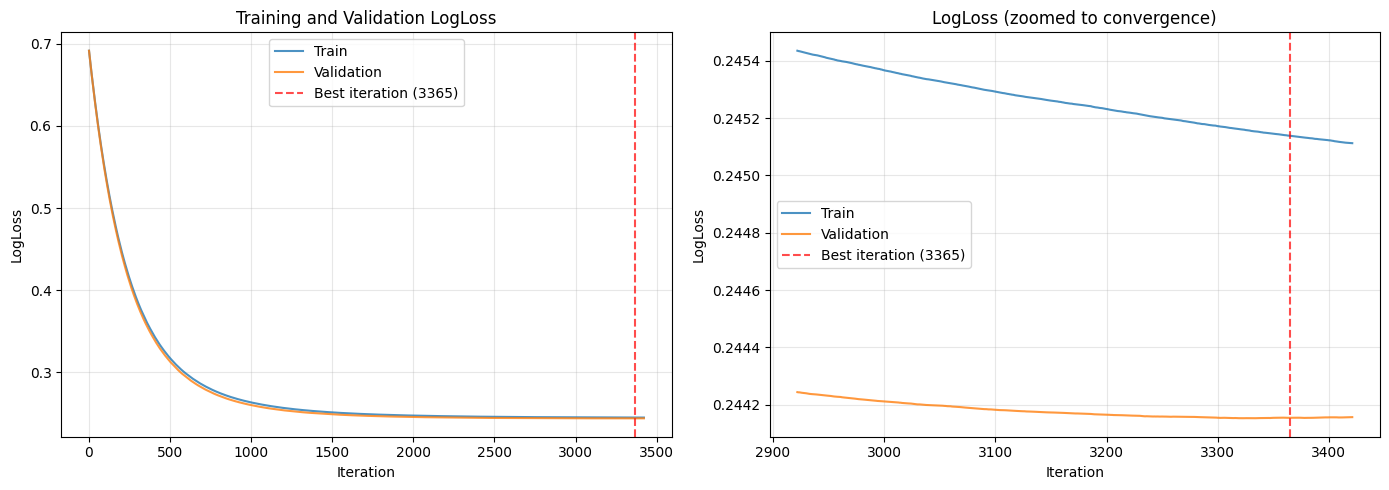

Saved: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\learning_curves.png

Final Training LogLoss: 0.2451
Final Validation LogLoss: 0.2442
Gap (Val - Train): -0.0010


In [15]:
# Plot training and validation learning curves

evals_result = model.get_evals_result()

train_logloss = evals_result.get('learn', {}).get('Logloss', [])
val_logloss = evals_result.get('validation', {}).get('Logloss', [])
if not val_logloss:
    val_logloss = evals_result.get('validation_0', {}).get('Logloss', [])

if not train_logloss or not val_logloss:
    print('Warning: Could not extract learning curves from model.')
    print('Available eval results:', evals_result.keys())
else:
    iterations = range(1, len(train_logloss) + 1)
    best_iter = model.get_best_iteration()
    best_iter_idx = int(best_iter) if best_iter is not None else len(train_logloss) - 1
    best_iter_plot = best_iter_idx + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: LogLoss curves
    ax1 = axes[0]
    ax1.plot(iterations, train_logloss, label='Train', alpha=0.8)
    ax1.plot(iterations, val_logloss, label='Validation', alpha=0.8)
    ax1.axvline(x=best_iter_plot, color='red', linestyle='--',
                label=f'Best iteration ({best_iter_plot})', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('LogLoss')
    ax1.set_title('Training and Validation LogLoss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: LogLoss curves (zoomed to last portion)
    ax2 = axes[1]
    start_idx = max(0, len(train_logloss) - 500)
    ax2.plot(list(iterations)[start_idx:], train_logloss[start_idx:], label='Train', alpha=0.8)
    ax2.plot(list(iterations)[start_idx:], val_logloss[start_idx:], label='Validation', alpha=0.8)
    ax2.axvline(x=best_iter_plot, color='red', linestyle='--',
                label=f'Best iteration ({best_iter_plot})', alpha=0.7)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('LogLoss')
    ax2.set_title('LogLoss (zoomed to convergence)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'learning_curves.png', dpi=150)
    plt.show()
    print(f'Saved: {PLOTS_DIR / "learning_curves.png"}')

    print()
    print(f'Final Training LogLoss: {train_logloss[best_iter_idx]:.4f}')
    print(f'Final Validation LogLoss: {val_logloss[best_iter_idx]:.4f}')
    print(f'Gap (Val - Train): {val_logloss[best_iter_idx] - train_logloss[best_iter_idx]:.4f}')


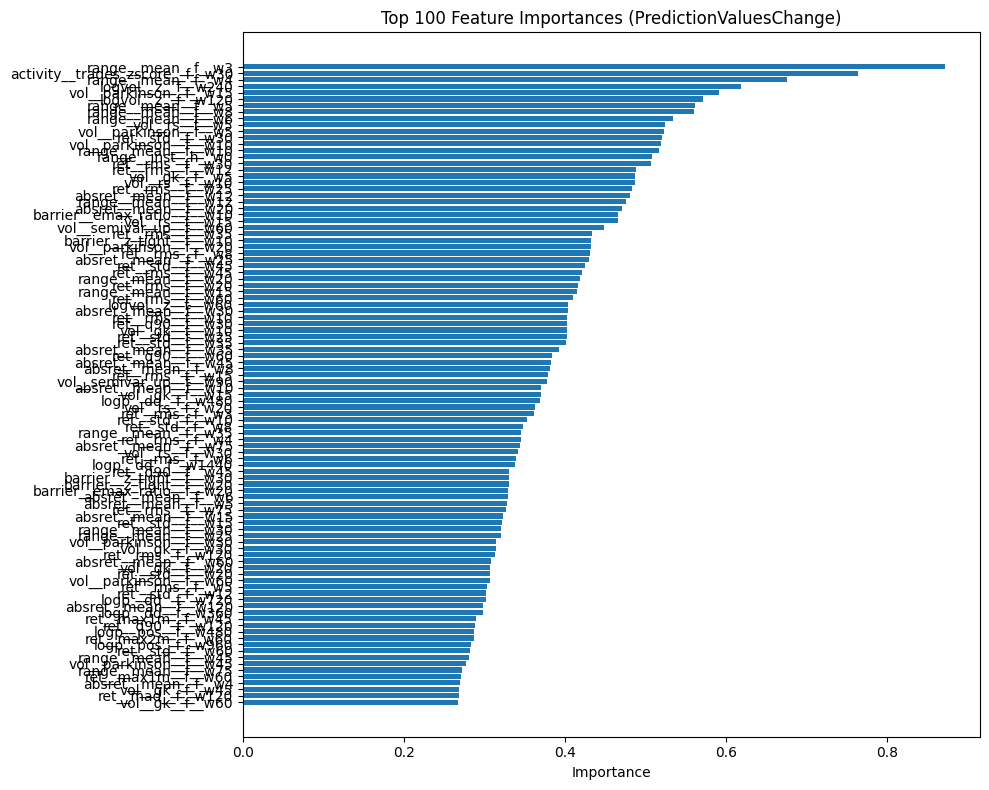

Saved: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\feature_importance_prediction.png


In [16]:
# Feature importance with respect to prediction (PredictionValuesChange)

importance_type = 'PredictionValuesChange'
importances = model.get_feature_importance(data=val_pool, type=importance_type)
importance_df = (
    pd.DataFrame({'feature': feature_list, 'importance': importances})
    .sort_values('importance', ascending=False)
)

top_n = 100
top_df = importance_df.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_df['feature'], top_df['importance'])
ax.set_title(f'Top {top_n} Feature Importances ({importance_type})')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'feature_importance_prediction.png', dpi=150)
plt.show()
print(f'Saved: {PLOTS_DIR / "feature_importance_prediction.png"}')


In [17]:
# Evaluate on validation + test using CatBoost Pools (spec Section 0 + 11)

test_pool = create_catboost_pool(test_df, feature_list)

# Predict
p_val = model.predict_proba(val_pool)[:, 1]
p_test = model.predict_proba(test_pool)[:, 1]

y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

# Compute metrics
val_metrics = utils.compute_all_metrics(y_val_np, p_val)
test_metrics = utils.compute_all_metrics(y_test_np, p_test)
metrics_json = {
    'validation': {
        'n_samples': int(len(y_val_np)),
        'base_rate': float(y_val_np.mean()),
        **val_metrics,
    },
    'test': {
        'n_samples': int(len(y_test_np)),
        'base_rate': float(y_test_np.mean()),
        **test_metrics,
    },
    'best_hyperparameters': best_params,
    'best_iteration': model.get_best_iteration(),
}

# Calibration by regime
cal_by_regime_val = utils.calibration_by_regime(y_val_np, p_val, regime_signal_val, n_bins=10)
cal_by_regime_test = utils.calibration_by_regime(y_test_np, p_test, regime_signal_test, n_bins=10)
metrics_json['calibration_by_regime'] = {
    'validation': cal_by_regime_val,
    'test': cal_by_regime_test,
}

# Save outputs
utils.save_json(ANALYTICS_DIR / 'metrics.json', metrics_json)
utils.save_json(ANALYTICS_DIR / 'calibration_by_regime.json', metrics_json['calibration_by_regime'])

thresh_df_val = utils.threshold_analysis(y_val_np, p_val)
thresh_df_val['split'] = 'validation'
thresh_df_test = utils.threshold_analysis(y_test_np, p_test)
thresh_df_test['split'] = 'test'
thresh_df = pd.concat([thresh_df_val, thresh_df_test], ignore_index=True)
thresh_df.to_csv(ANALYTICS_DIR / 'threshold_analysis.csv', index=False)

print('Saved metrics:', ANALYTICS_DIR / 'metrics.json')
print('Saved calibration:', ANALYTICS_DIR / 'calibration_by_regime.json')
print('Saved thresholds:', ANALYTICS_DIR / 'threshold_analysis.csv')
print()
print('Validation/Test Metrics:')
display(pd.DataFrame([metrics_json['validation'], metrics_json['test']], index=['validation', 'test']))

Saved metrics: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\metrics.json
Saved calibration: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\calibration_by_regime.json
Saved thresholds: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\threshold_analysis.csv

Validation/Test Metrics:


,n_samples,base_rate,roc_auc,pr_auc,log_loss,brier_score,ece
validation,22641,0.114218,0.816483,0.368899,0.285853,0.085266,0.009187
test,22642,0.069649,0.813315,0.263468,0.208192,0.057569,0.002277


In [18]:
# Plot styling and split colors
sns.set_style('whitegrid')
split_colors = {
    'validation': '#e67e22',
    'test': '#3498db',
}
calibration_bins = 10
hist_bins = 50

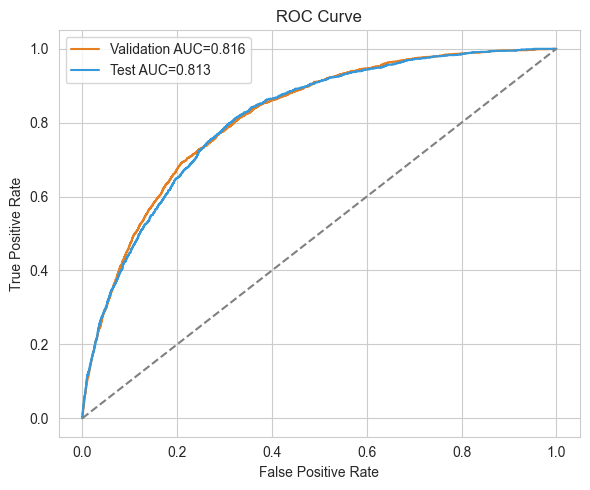

In [19]:
# ROC curve (validation vs test)
fpr_val, tpr_val, _ = roc_curve(y_val_np, p_val)
fpr_test, tpr_test, _ = roc_curve(y_test_np, p_test)

roc_auc_val = roc_auc_score(y_val_np, p_val)
roc_auc_test = roc_auc_score(y_test_np, p_test)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr_val, tpr_val, label=f'Validation AUC={roc_auc_val:.3f}', color=split_colors['validation'])
ax.plot(fpr_test, tpr_test, label=f'Test AUC={roc_auc_test:.3f}', color=split_colors['test'])
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'roc_curve.png', dpi=150)
plt.show()
plt.close(fig)

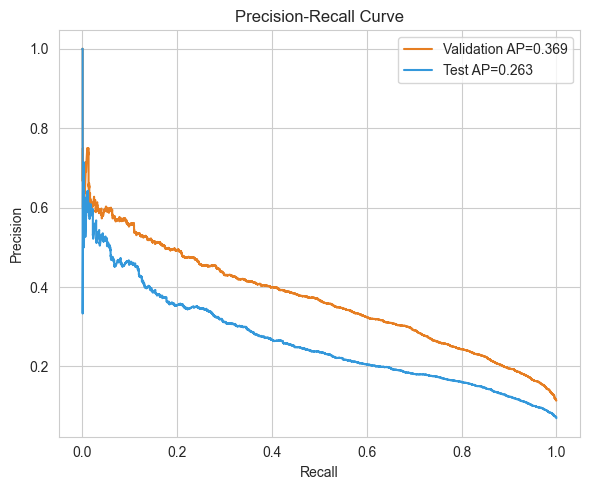

In [20]:
# Precision-Recall curve (validation vs test)
prec_val, rec_val, _ = precision_recall_curve(y_val_np, p_val)
prec_test, rec_test, _ = precision_recall_curve(y_test_np, p_test)

ap_val = average_precision_score(y_val_np, p_val)
ap_test = average_precision_score(y_test_np, p_test)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(rec_val, prec_val, label=f'Validation AP={ap_val:.3f}', color=split_colors['validation'])
ax.plot(rec_test, prec_test, label=f'Test AP={ap_test:.3f}', color=split_colors['test'])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'pr_curve.png', dpi=150)
plt.show()
plt.close(fig)

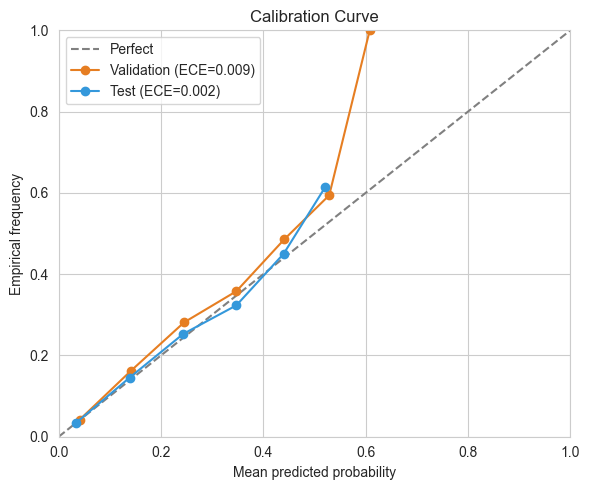

In [21]:
# Calibration curve (validation vs test)
ece_val = utils.expected_calibration_error(y_val_np, p_val, n_bins=calibration_bins)
ece_test = utils.expected_calibration_error(y_test_np, p_test, n_bins=calibration_bins)

fig, ax = plt.subplots(figsize=(6,5))
utils.plot_calibration_curve(
    y_val_np,
    p_val,
    n_bins=calibration_bins,
    ax=ax,
    label=f'Validation (ECE={ece_val:.3f})',
    color=split_colors['validation'],
    plot_perfect=True,
    show_ece=False,
)
utils.plot_calibration_curve(
    y_test_np,
    p_test,
    n_bins=calibration_bins,
    ax=ax,
    label=f'Test (ECE={ece_test:.3f})',
    color=split_colors['test'],
    plot_perfect=False,
    show_ece=False,
)
ax.set_title('Calibration Curve')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'calibration_curve.png', dpi=150)
plt.show()
plt.close(fig)

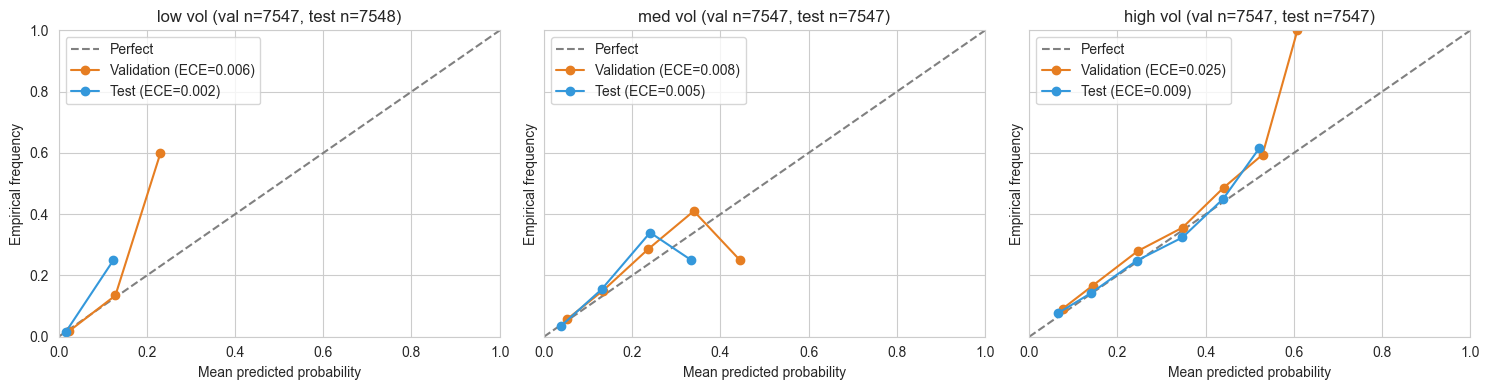

In [22]:
# Calibration by volatility regime (validation vs test)
regimes_val = pd.qcut(regime_signal_val, 3, labels=['low', 'med', 'high'])
regimes_test = pd.qcut(regime_signal_test, 3, labels=['low', 'med', 'high'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, regime in zip(axes, ['low', 'med', 'high']):
    mask_val = np.asarray(regimes_val == regime)
    mask_test = np.asarray(regimes_test == regime)

    if mask_val.sum() == 0 and mask_test.sum() == 0:
        ax.set_title(f'{regime} vol (n=0)')
        ax.axis('off')
        continue

    plotted_perfect = False
    if mask_val.sum() > 0:
        ece_val = utils.expected_calibration_error(
            y_val_np[mask_val],
            p_val[mask_val],
            n_bins=calibration_bins,
        )
        utils.plot_calibration_curve(
            y_val_np[mask_val],
            p_val[mask_val],
            n_bins=calibration_bins,
            ax=ax,
            label=f'Validation (ECE={ece_val:.3f})',
            color=split_colors['validation'],
            plot_perfect=True,
            show_ece=False,
        )
        plotted_perfect = True

    if mask_test.sum() > 0:
        ece_test = utils.expected_calibration_error(
            y_test_np[mask_test],
            p_test[mask_test],
            n_bins=calibration_bins,
        )
        utils.plot_calibration_curve(
            y_test_np[mask_test],
            p_test[mask_test],
            n_bins=calibration_bins,
            ax=ax,
            label=f'Test (ECE={ece_test:.3f})',
            color=split_colors['test'],
            plot_perfect=not plotted_perfect,
            show_ece=False,
        )

    ax.set_title(
        f'{regime} vol (val n={int(mask_val.sum())}, test n={int(mask_test.sum())})'
    )

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'calibration_by_regime.png', dpi=150)
plt.show()
plt.close(fig)

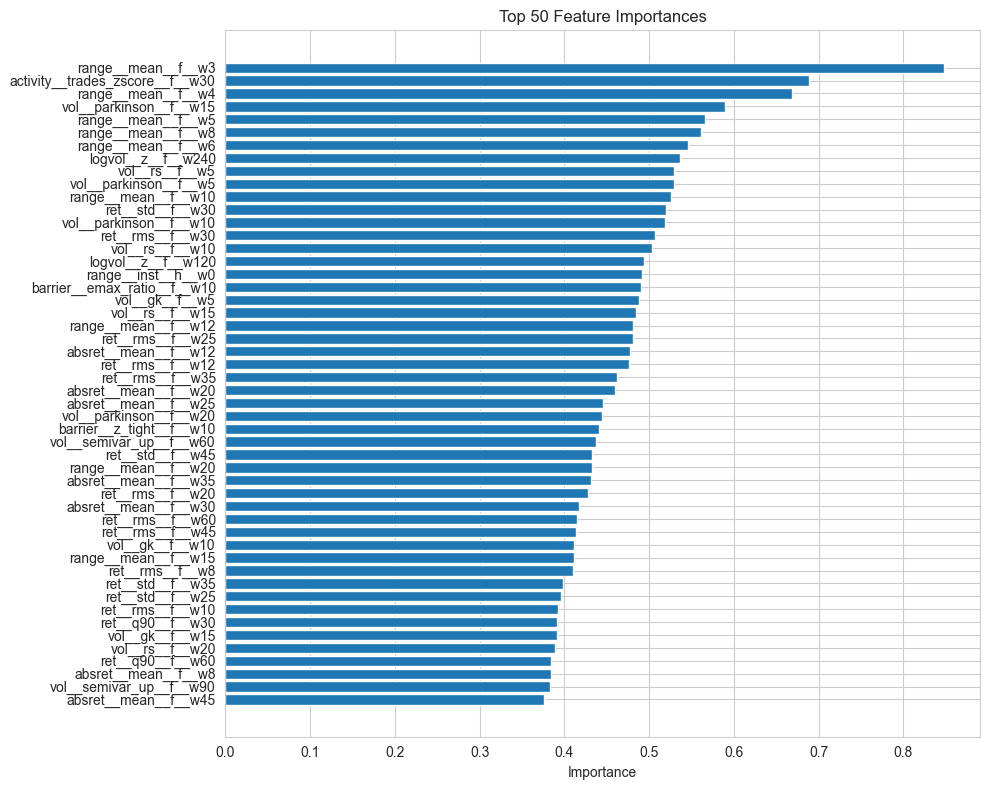

In [23]:
# Feature importance (top 30)
fig, ax = plt.subplots(figsize=(10,8))
utils.plot_feature_importance(model, feature_list, top_n=50, ax=ax)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'feature_analysis.png', dpi=150)
plt.show()
plt.close(fig)

c:\Users\vitil\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\vitil\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\vitil\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

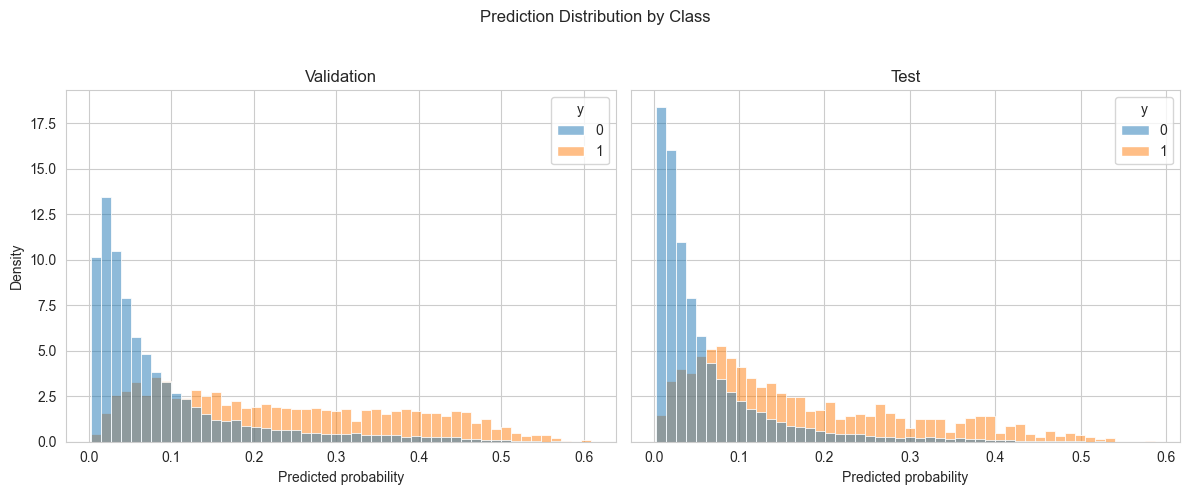

In [24]:
# Prediction distribution by class (validation vs test)
plot_df_val = pd.DataFrame({'y': y_val_np, 'p': p_val})
plot_df_test = pd.DataFrame({'y': y_test_np, 'p': p_test})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.histplot(
    data=plot_df_val,
    x='p',
    hue='y',
    bins=hist_bins,
    stat='density',
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title('Validation')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Density')

sns.histplot(
    data=plot_df_test,
    x='p',
    hue='y',
    bins=hist_bins,
    stat='density',
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title('Test')
axes[1].set_xlabel('Predicted probability')

fig.suptitle('Prediction Distribution by Class')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOTS_DIR / 'prediction_distribution.png', dpi=150)
plt.show()
plt.close(fig)

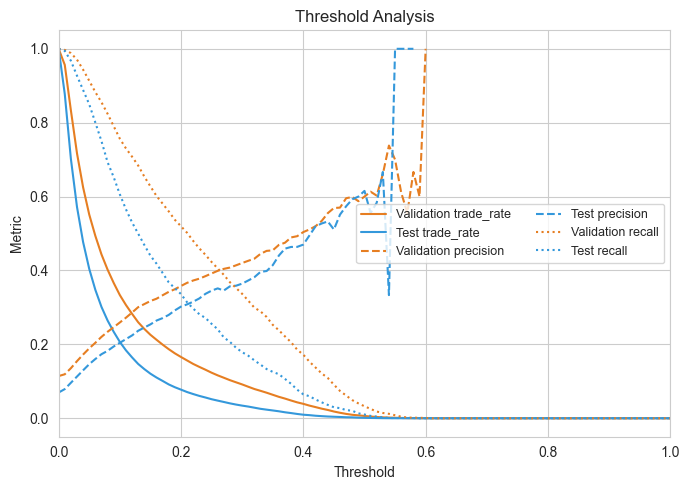

In [25]:
# Threshold analysis (validation vs test)
fig, ax = plt.subplots(figsize=(7,5))

metric_styles = {
    'trade_rate': '-',
    'precision': '--',
    'recall': ':',
}

for metric, linestyle in metric_styles.items():
    ax.plot(
        thresh_df_val['threshold'],
        thresh_df_val[metric],
        label=f'Validation {metric}',
        color=split_colors['validation'],
        linestyle=linestyle,
    )
    ax.plot(
        thresh_df_test['threshold'],
        thresh_df_test[metric],
        label=f'Test {metric}',
        color=split_colors['test'],
        linestyle=linestyle,
    )

ax.set_title('Threshold Analysis')
ax.set_xlabel('Threshold')
ax.set_ylabel('Metric')
ax.set_xlim(0, 1)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'threshold_analysis.png', dpi=150)
plt.show()
plt.close(fig)